```
✅ Feature engineering pipeline (reusable for train + validation)
✅ EDA — distribution, time series, boxplot, heatmap, ADF
✅ Added srp_rate — strongest new feature (coef=0.41, z=34)
✅ Trained SARIMAX(1,1,1)(1,0,1,7)
✅ Saved model + config

In [28]:
#Installs
!pip install holidays statsmodels

In [29]:
#Imports
import pandas as pd
import numpy as np
import pickle
import holidays
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [30]:
# Features passed into SARIMAX model

EXOG_COLS = ["temp_avg", "is_weekend", "is_holiday", "srp_rate", "lag1"]

# # The 6 holidays SRP EZ-3 plan treats as off-peak — same as weekends,
# no on-peak hours apply on these days
# Source: SRP EZ-3 plan conditions

TARGET_HOLIDAYS = {
    "New Year's Day",
    "New Year's Day (Observed)",
    "Memorial Day",
    "Independence Day",
    "Independence Day (Observed)",
    "Labor Day",
    "Thanksgiving Day",
    "Christmas Day",
    "Christmas Day (Observed)",
}

**Helper functions**

In [31]:
# 1- Data Load
def _load_raw(usage_filepath: str, cost_filepath: str) -> pd.DataFrame:
    """
    Load and merge SRP usage and cost CSV files.
    - Usage file: Off-peak kWh, On-peak kWh, temperature
    - Cost file: Off-peak cost, On-peak cost only
    Both files share the same Usage date so we merge on that.
    """
    df_usage = pd.read_csv(usage_filepath, skipfooter=1, engine='python')
    df_cost  = pd.read_csv(cost_filepath,  skipfooter=1, engine='python',
                           usecols=['Usage date', 'Off-peak cost', 'On-peak cost'])

    # Merge on Usage date — usage file is the base
    df = df_usage.merge(df_cost, on='Usage date', how='left')

    # Drop meter read date — not needed
    if 'Meter read date' in df.columns:
        df.drop('Meter read date', axis=1, inplace=True)

    return df

In [32]:
# 2- Compute total cost
def _compute_total_cost(df: pd.DataFrame) -> pd.DataFrame:
    """Convert Off-peak and On-peak cost strings to a single numeric total."""
    df = df.copy()
    df['total_cost_numeric'] = (
        df['Off-peak cost'].str.replace('$', '', regex=False).astype(float) +
        df['On-peak cost'].str.replace('$', '', regex=False).astype(float)
    ).round(2)
    return df


In [33]:
# 3-set datetime
def _set_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    """Parse Usage date and set as daily DatetimeIndex."""
    df = df.copy()
    df['Usage date'] = pd.to_datetime(df['Usage date'])
    df = df.set_index('Usage date').asfreq('D')
    return df


In [34]:
#4- temp features
def _add_temp_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add average temperature — midpoint of daily high and low."""
    df = df.copy()
    df['temp_avg'] = (
        df['High temperature (F)'] + df['Low temperature (F)']
    ) / 2
    return df

In [ ]:
#5-Calendar features
def _add_calendar_features(df: pd.DataFrame, years: list) -> pd.DataFrame:
    """Add is_weekend and is_holiday features."""
    df = df.copy()

    # 1 if Saturday or Sunday, else 0
    df['is_weekend'] = (df.index.weekday >= 5).astype(int)

    # Get all US holidays for the given years, then keep only SRP's 6
    all_holidays = holidays.US(state='AZ', years=years, observed=True)
    srp_holiday_dates = pd.to_datetime([
        date for date, name in all_holidays.items()
        if name in TARGET_HOLIDAYS
    ])

    # 1 if the day is one of SRP's 6 off-peak holidays, else 0
    df['is_holiday'] = df.index.normalize().isin(srp_holiday_dates).astype(int)

    return df


In [35]:
##6-srp rate
def _add_srp_rate(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add SRP EZ-3 blended rate weighted by actual kWh usage.
    Captures both off-peak and on-peak pricing per season.

    Season          Months              Off-peak    On-peak
    Winter          Nov, Dec, Jan-Apr    9.70c      12.94c
    Summer          May,Jun,Sep,Oct     10.30c      30.96c
    Summer Peak     Jul, Aug            10.69c      36.61c

    Also adds season label for analysis (not used as model feature).
    Source: SRP EZ-3 3-6pm plan rate schedule
    """
    df = df.copy()
    month = df.index.month

    # Winter rates as default (Nov-Apr)
    df['srp_offpeak_rate'] = 9.70
    df['srp_onpeak_rate']  = 12.94
    df['season']           = 'winter'

    # Summer (May, Jun, Sep, Oct)
    df.loc[month.isin([5, 6, 9, 10]), 'srp_offpeak_rate'] = 10.30
    df.loc[month.isin([5, 6, 9, 10]), 'srp_onpeak_rate']  = 30.96
    df.loc[month.isin([5, 6, 9, 10]), 'season']           = 'summer'

    # Summer Peak (Jul, Aug)
    df.loc[month.isin([7, 8]), 'srp_offpeak_rate'] = 10.69
    df.loc[month.isin([7, 8]), 'srp_onpeak_rate']  = 36.61
    df.loc[month.isin([7, 8]), 'season']           = 'summer_peak'

    # Blended rate weighted by actual kWh usage
    total_kwh = df['Off-peak kWh'] + df['On-peak kWh']
    df['srp_rate'] = (
        (df['Off-peak kWh'] * df['srp_offpeak_rate'] +
         df['On-peak kWh'] * df['srp_onpeak_rate']) /
        total_kwh
    ).round(4)

    # Drop separate rates — srp_rate replaces them
    df.drop(columns=['srp_offpeak_rate', 'srp_onpeak_rate'], inplace=True)

    return df

In [36]:
#7-lag features
def _add_lag_features(df: pd.DataFrame, lag_days: list = [1],
                      lag1_seed: float = None) -> pd.DataFrame:
    """
    Add lag features — previous days' actual costs.

    lag_days: list of how many days back to look.
              Default [1] = just yesterday.
              Example [1, 7] = yesterday + same day last week.

    lag1_seed: actual cost of the day before this file starts.
               Example: file starts Feb 1 -> pass Jan 31 cost (1.34)
               Leave empty for training data — no seed needed.
    """
    df = df.copy()

    for lag in lag_days:
        col_name = f'lag{lag}'

        if lag == min(lag_days) and lag1_seed is not None:
            # Attach seed as the day before row 0, then shift
            previous_day = pd.Series(
                [lag1_seed],
                index=[df.index[0] - pd.Timedelta(days=lag)]
            )
            all_costs = pd.concat([previous_day, df['total_cost_numeric']])
            df[col_name] = all_costs.shift(lag).loc[df.index]
        else:
            # For training data, previous days are already in the file
            df[col_name] = df['total_cost_numeric'].shift(lag)

    return df

**Main Pipeline**

In [37]:

def build_features(
    usage_filepath: str,
    cost_filepath: str,
    lag_days: list = [1],
    lag1_seed: float = None,
    drop_na: bool = True
) -> pd.DataFrame:
    """
    Full feature engineering pipeline for SRP energy cost data.
    Works for both training and validation/test data.

    usage_filepath: path to SRP daily usage CSV
    cost_filepath:  path to SRP daily cost CSV

    lag_days: which lag features to add. Default [1] = yesterday only.

    lag1_seed: actual cost of the day before this file starts.
               Example: file starts Feb 1 -> pass Jan 31 cost (1.34)
               Leave empty for training data — no seed needed.

    drop_na: drop rows with NaN after feature engineering. Default True.
    """
    df = _load_raw(usage_filepath, cost_filepath)
    df = _compute_total_cost(df)
    df = _set_datetime_index(df)
    df = _add_temp_features(df)

    # Detect years dynamically from the data itself
    years = df.index.year.unique().tolist()
    df = _add_calendar_features(df, years=years)
    df = _add_srp_rate(df)
    df = _add_lag_features(df, lag_days=lag_days, lag1_seed=lag1_seed)

    if drop_na:
        df = df.dropna()

    return df

**Quick Summary Helper**

In [56]:
def describe_dataset(df: pd.DataFrame, label: str = "Dataset") -> None:
    """Print a quick summary of a prepared dataset."""
    print(f"\n{'─'*50}")
    print(f" {label}")
    print(f"{'─'*50}")
    print(f" Rows          : {len(df)}")
    print(f" Date range    : {df.index[0].date()} -> {df.index[-1].date()}")
    print(f" Cost mean     : ${df['total_cost_numeric'].mean():.2f}")
    print(f" Cost range    : ${df['total_cost_numeric'].min():.2f} - ${df['total_cost_numeric'].max():.2f}")
    print(f" Weekends      : {df['is_weekend'].sum()}")
    print(f" Holidays      : {df['is_holiday'].sum()}")
    print(f" Temp range    : {df['temp_avg'].min():.1f}F - {df['temp_avg'].max():.1f}F")
    print(f" Seasons       : {df['season'].value_counts().to_dict()}")
    print(f" SRP rate range: {df['srp_rate'].min():.4f} – {df['srp_rate'].max():.4f} c/kWh")
    #print(f" Avg rate range: {sorted(df['avg_rate'].unique().tolist())} c/kWh")
    #print(f" Off-peak rates: {sorted(df['srp_offpeak_rate'].unique().tolist())} c/kWh")
    #print(f" On-peak rates : {sorted(df['srp_onpeak_rate'].unique().tolist())} c/kWh")
    print(f"{'─'*50}\n")

In [39]:
# First run build features on training data
# filepaths
df_train = build_features('/content/dailyUsage1_31_2023_to_1_30_2026.csv', '/content/dailyCost1_31_2023_to_1_30_2026.csv')

In [40]:
df_train.head(3)

,Off-peak kWh,On-peak kWh,High temperature (F),Low temperature (F),Off-peak cost,On-peak cost,total_cost_numeric,temp_avg,is_weekend,is_holiday,season,srp_rate,lag1
Usage date,,,,,,,,,,,,,
2023-02-01,9,2,66,45,$0.93,$0.28,1.21,55.5,0,0,winter,10.2891,1.31
2023-02-02,9,1,69,42,$0.93,$0.14,1.07,55.5,0,0,winter,10.0240,1.21
2023-02-03,10,2,73,47,$1.03,$0.28,1.31,60.0,0,0,winter,10.2400,1.07


**Data Overview**

In [41]:
print(df_train.shape)
print(df_train.dtypes)
df_train.describe()

(1095, 13)
Off-peak kWh              int64
On-peak kWh               int64
High temperature (F)      int64
Low temperature (F)       int64
Off-peak cost            object
On-peak cost             object
total_cost_numeric      float64
temp_avg                float64
is_weekend                int64
is_holiday                int64
season                   object
srp_rate                float64
lag1                    float64
dtype: object


,Off-peak kWh,On-peak kWh,High temperature (F),Low temperature (F),total_cost_numeric,temp_avg,is_weekend,is_holiday,srp_rate,lag1
count,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000
mean,18.810046,2.236530,88.240183,65.024658,2.689397,76.632420,0.284932,0.016438,11.442985,2.689708
std,11.738407,3.173781,15.951017,14.903294,2.097263,15.225388,0.451588,0.127212,2.307639,2.097034
min,3.000000,0.000000,52.000000,34.000000,0.340000,44.500000,0.000000,0.000000,9.700000,0.340000
25%,9.000000,0.000000,75.000000,52.000000,1.115000,63.500000,0.000000,0.000000,9.994500,1.120000
50%,14.000000,1.000000,89.000000,64.000000,1.690000,76.000000,0.000000,0.000000,10.300000,1.690000
75%,27.000000,2.000000,103.000000,78.000000,3.840000,90.500000,1.000000,0.000000,12.178200,3.840000
max,66.000000,14.000000,117.000000,93.000000,9.840000,104.000000,1.000000,1.000000,19.797000,9.840000


**Target Variable Distribution**

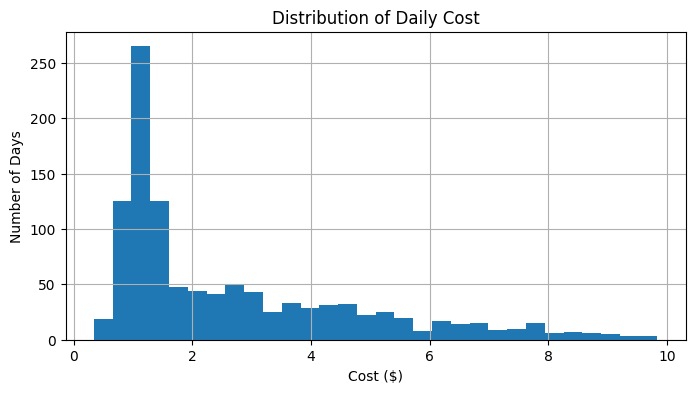

In [42]:
import matplotlib.pyplot as plt
df_train['total_cost_numeric'].hist(bins=30, figsize=(8,4))
plt.title('Distribution of Daily Cost')
plt.xlabel('Cost ($)')
plt.ylabel('Number of Days')
plt.show()

This is a classic **right-skewed distribution.**

**Why right-skewed:**

Phoenix has 6 months of winter (cheap) vs 4 months summer + 2 months summer peak (expensive)

Winter days are tightly clustered — low AC usage, predictable

Summer days are spread wide — depends heavily on how hot it gets




**Cost over time**

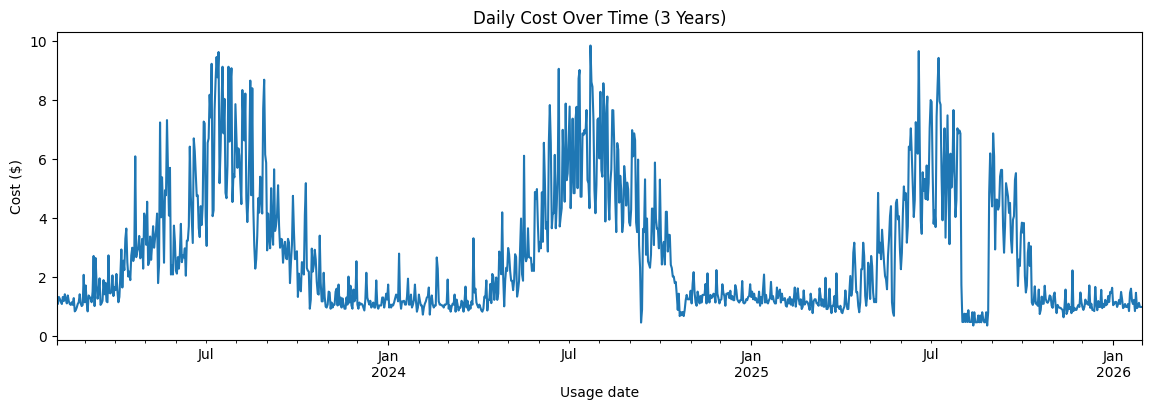

In [43]:
df_train['total_cost_numeric'].plot(figsize=(14,4),
                                     title='Daily Cost Over Time (3 Years)')
plt.ylabel('Cost ($)')
plt.show()

**Feature correlation heatmap**

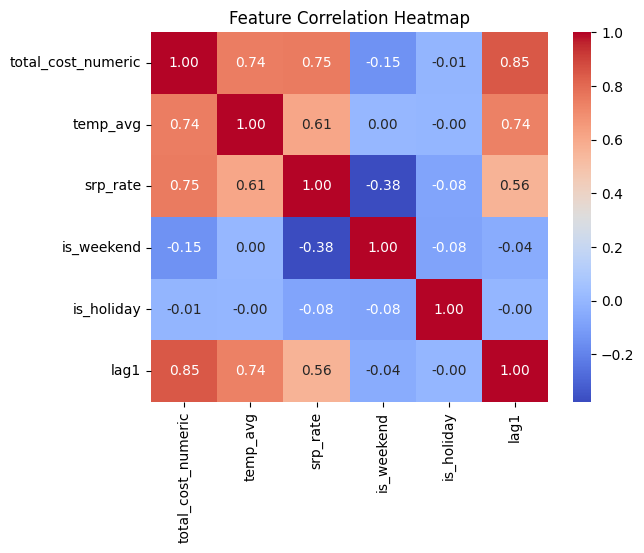

In [44]:

corr = df_train[['total_cost_numeric','temp_avg','srp_rate','is_weekend','is_holiday','lag1']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

Feature Correlation Heatmap
```
Correlations with total_cost_numeric:
  lag1        +0.85  ← strongest predictor — cost is day-persistent
  srp_rate    +0.75  ← season/pricing directly drives cost
  temp_avg    +0.74  ← temperature drives AC usage
  is_weekend  -0.15  ← weekends cheaper (no on-peak charges)
  is_holiday  -0.01  ← rare (18 days) but retained for accuracy

No multicollinearity issues between features:
  All feature-to-feature correlations are reasonable
  srp_rate ↔ is_weekend = -0.38 (weekends have lower blended rates)
  srp_rate ↔ temp_avg   = +0.61 (both driven by season — expected)
```
All 5 features justified and retained in EXOG_COLS.

**Stationarity test (ADF)**

In [45]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df_train['total_cost_numeric'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Stationary' if result[1] < 0.05 else 'Not Stationary')

ADF Statistic: -2.9590
p-value: 0.0389
Stationary


```
Stationary ✅
Winter cost always returns to ~$1.00–$1.50
Summer cost always returns to ~$3–$6
Pattern repeats every year consistently
No permanent upward or downward drift over 3 years
```
p-value = 0.0389 < 0.05 → stationary ✅
```
Null hypothesis (H0):   → NOT stationary
Alternative (H1):       → IS stationary

p-value < 0.05 → reject H0 → stationary  ✅
p-value > 0.05 → fail to reject H0 → not stationary


**Stationarity Test (Augmented Dickey-Fuller)**
```
ADF Statistic : -2.9590
p-value       : 0.0389  < 0.05 → Statistically stationary ✅

However — the time series plot clearly shows strong annual
seasonality (costs spike every summer). The ADF test detects
no unit root but does not test for seasonality.

Decision: Apply first differencing (d=1) in SARIMAX to remove
any residual trend, and seasonal differencing (D=0, s=7) to
capture weekly patterns — consistent with original model order
SARIMAX(1,1,1)(1,0,1,7).

Trust the visual + domain knowledge over the test alone.

**Season distribution + correlation matrix**

In [46]:
#
df_train['season'].value_counts()

,count
season,
winter,543
summer,366
summer_peak,186


Training Data: Jan 2023 → Jan 2026 (3 years)
```
Season        Days    Months
Winter        543     Nov–Apr (6 months)
Summer        366     May, Jun, Sep, Oct (4 months)
Summer Peak   186     Jul–Aug (2 months)
Total         1,095   = exactly 3 years ✅
```

All 3 seasons well represented — no imbalance issues.

**Cost by season boxplot**

<Axes: title={'center': 'total_cost_numeric'}, xlabel='season'>

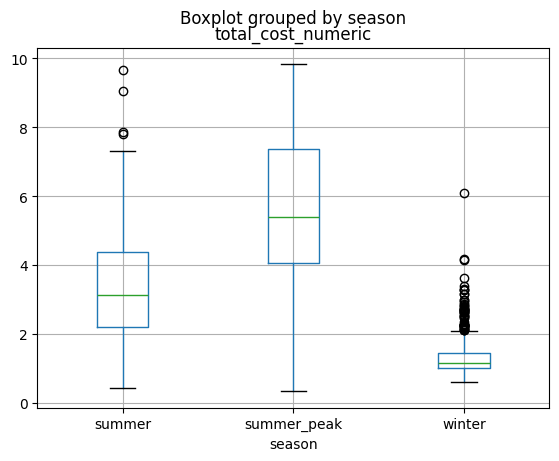

In [49]:
# Cost by season boxplot
df_train.boxplot(column='total_cost_numeric', by='season')

Median daily cost (green line):

Winter: ~$1.25 ← cheapest

Summer: ~$3.20

Summer Peak: ~$5.50 ← most expensive

That's a 4x difference between winter and summer peak — which strongly validates adding srp_rate as a feature.

Spread (box size = middle 50% of days):

Winter: very tight ($0.90–$2.10) — costs are predictable

Summer: moderate ($2.30–$4.30) — more variation

Summer Peak: wide ($4.10–$7.40) — most unpredictable

Outliers (circles above the whiskers):

Winter has many outliers above $2.10 — likely extreme heat days in Nov/Apr shoulder months

Summer and Summer Peak have a few extreme outliers near `$`9–`$`10 — probably heatwave days with AC running all day

Key takeaway for our model:

Summer Peak will be the hardest season to predict accurately — widest spread, highest variance. Your MAE will likely be higher for summer peak days than winter. That's worth calling out explicitly in our validation analysis when we break down MAE by season.

**Training**

In [50]:
# Train SARIMAX model on 3 years of SRP household energy data
# Features: temp_avg, is_weekend, is_holiday, srp_rate, lag1
# Order: SARIMAX(1,1,1)(1,0,1,7) — determined from original ACF/PACF analysis

from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

X_train = df_train[EXOG_COLS]
y_train = df_train['total_cost_numeric']

model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=True,
    enforce_invertibility=True
)

final_model = model.fit(disp=False)
print(final_model.summary())

                                     SARIMAX Results                                     
Dep. Variable:                total_cost_numeric   No. Observations:                 1095
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -1204.505
Date:                           Wed, 06 May 2026   AIC                           2429.011
Time:                                   12:34:37   BIC                           2478.987
Sample:                               02-01-2023   HQIC                          2447.922
                                    - 01-30-2026                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp_avg       0.0396      0.005      7.368      0.000       0.029       0.050
is_weekend     0.1383      0.075      1.853

**SARIMAX(1,1,1)(1,0,1,7) Training Results**

**AIC=2429** — the best model! ✅

AIC stands for Akaike Information Criterion — it measures how well the model fits the data while penalizing complexity.

Lower AIC = better model

can't say "2429 is good or bad" in isolation, need to compare models

Original model AIC = 2958  ← worse
Current model  AIC = 2429  ← better by 529 points

**srp_rate coef=0.41, z=34 **✅ strongest feature

coef=0.41 means:Every 1¢ increase in srp_rate → $0.41 increase in predicted cost

Winter srp_rate ~9.70¢, Summer Peak ~19¢ → difference of ~9¢ × 0.41 = $3.69 cost difference just from season. That's huge and matches your data.

z=34 means:This coefficient is 34 standard deviations away from zero

Anything above z=2 is considered statistically significant. z=34 is extremely strong — essentially zero chance this feature is irrelevant.

**lag1 significant** ✅

p-value=0.000 → yesterday's cost reliably predicts today's cost. Makes intuitive sense — if yesterday was expensive (hot day, AC running), today likely is too.

**temp_avg significant** ✅

p-value=0.000 → temperature reliably predicts cost. Hotter day → more AC → higher cost.


**Ljung-Box p=0.76 → no autocorrelation** ✅

This tests whether the model's errors follow a pattern.

p > 0.05 → errors are random → model captured all patterns ✅

p < 0.05 → errors still have patterns → model missed something ❌

p=0.76 means the residuals are essentially random noise — the model has learned everything it can from the data.



In [52]:
# model save to colab content
import pickle

with open('cost_forecast_model_latest.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("Model saved → cost_forecast_model_latest.pkl")

Model saved → cost_forecast_model_latest.pkl


**Model config:** This documents everything about the model in one place

In [53]:
#save the model config so you always know what features and order were used:
import json

model_config = {
    "model_type": "SARIMAX",
    "order": [1, 1, 1],
    "seasonal_order": [1, 0, 1, 7],
    "exog_cols": EXOG_COLS,
    "target": "total_cost_numeric",
    "training_period": {
        "start": str(df_train.index[0].date()),
        "end": str(df_train.index[-1].date())
    },
    "training_rows": len(df_train),
    "aic": round(final_model.aic, 3),
    "bic": round(final_model.bic, 3),
    "notes": "srp_rate = blended rate weighted by actual kWh usage per day"
}

with open('model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print("Config saved → model_config.json")

Config saved → model_config.json


** Note —** training period shows start: 2023-02-01 not 2023-01-31. That's because the first row gets dropped due to lag1 being NaN (no previous day available). That's expected and correct.

Now have two files to keep safe:
```
cost_forecast_model_latest.pkl  ← trained model
model_config.json               ← model documentation

**Load validation data**



**data from 1‎/31/2026 to 5‎/1‎/2026**
```
Jan 31  → lag1 seed only (not evaluated)
Feb 1   → Mar 31 → 59 days (winter)
Apr 1   → Apr 30 → 30 days (shoulder/winter)
Total   → 89 days of validation

In [58]:
# Jan 31, 2026 — last known cost before validation window starts Feb 1
jan31_cost = 1.34

df_val = build_features(
    usage_filepath='/content/dailyUsage1_31_2026_to_5_1_2026.csv',
    cost_filepath='/content/dailyCost1_31_2026_to_5_1_2026.csv',
    lag1_seed=jan31_cost
)

describe_dataset(df_val, "Validation Set (Feb–May 2026)")


──────────────────────────────────────────────────
 Validation Set (Feb–May 2026)
──────────────────────────────────────────────────
 Rows          : 91
 Date range    : 2026-01-31 -> 2026-05-01
 Cost mean     : $1.25
 Cost range    : $0.62 - $2.93
 Weekends      : 26
 Holidays      : 0
 Temp range    : 54.5F - 87.5F
 Seasons       : {'winter': 90, 'summer': 1}
 SRP rate range: 9.7000 – 11.0255 c/kWh
──────────────────────────────────────────────────



**Quick observations:**

91 rows (Jan 31 seed + 90 validation days) ✅
```
Jan 31  → seed (not evaluated)
Feb 1–28  → 28 days
Mar 1–31  → 31 days
Apr 1–30  → 30 days
May 1     → 1 day
Total     → 90 validation days
```
SRP rate range 9.70–11.03 ✅ (mostly winter, one summer day May 1)

No holidays in this window ✅

Temp range 54.5–87.5°F — includes warm April days ✅

**Run predictions**

In [59]:
X_val = df_val[EXOG_COLS]
y_val = df_val['total_cost_numeric']

predictions = final_model.predict(
    start=df_val.index[0],
    end=df_val.index[-1],
    exog=X_val
)

**Evaluate**

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae  = mean_absolute_error(y_val, predictions)
rmse = np.sqrt(mean_squared_error(y_val, predictions))

print(f"MAE  : ${mae:.3f}")
print(f"RMSE : ${rmse:.3f}")

MAE  : $0.485
RMSE : $0.584



**Validation Results (Feb–May 2026, 90 days out-of-sample)**

MAE  : $0.485  — on average predictions are off by 48 cents (or) on average the model's prediction is 48 cents away from the actual cost.

RMSE : $0.584  — higher than MAE, meaning some days have larger errors

Context:
  Validation cost range : $0.62 – $2.93
  Validation cost mean  : $1.25
  MAE as % of mean      : $0.485 / $1.25 = 38.8%

Model performs on a winter/shoulder season window only.
Summer validation (Jul–Aug) expected to be harder due to
higher cost variance and extreme heat days.


RMSE : $0.584  — Root Mean Squared Error— penalizes larger errors more heavily

RMSE squares each error before averaging, then takes the square root.
This means larger errors are penalized more heavily than small ones.
```
Example:
  Day 1 error: $0.10  → squared = 0.01   (small, barely counts)
  Day 2 error: $1.50  → squared = 2.25   (large, counts a lot)

RMSE > MAE always — the gap between them tells you about error distribution:
  RMSE ($0.584) vs MAE ($0.485) → gap of $0.099
  Moderate gap → a few days with larger errors pulling RMSE up
  Likely the shoulder season days (Mar–Apr warm spikes)
  ```

**Error Analysis by Month and Season**

In [61]:
# Add predictions to df_val for analysis
df_val['predicted'] = predictions
df_val['error'] = df_val['total_cost_numeric'] - df_val['predicted']
df_val['abs_error'] = df_val['error'].abs()

# Error by month
print("MAE by month:")
print(df_val.groupby(df_val.index.month)['abs_error'].mean().round(3))

#Error by season
print("\nMAE by season:")
print(df_val.groupby('season')['abs_error'].mean().round(3))

MAE by month:
Usage date
1    0.052
2    0.425
3    0.564
4    0.469
5    0.663
Name: abs_error, dtype: float64

MAE by season:
season
summer    0.663
winter    0.483
Name: abs_error, dtype: float64


**MAE by month:**
```
January (seed)  : $0.052  ← near perfect (just the seed day)
February        : $0.425  ← best month
March           : $0.564  ← shoulder season struggle
April           : $0.469  ← better than March surprisingly
May 1           : $0.663  ← first summer day, hardest
```
**MAE by season:**
```
Winter(90 days)  : $0.483  ← solid
Summer(1 day)  : $0.663  ← only 1 day (May 1) but already harder
```
**Observations:**

```
April($0.469)is actually better than March ($0.564) — which is surprising. This suggests the shoulder season problem was more specific to certain March(Mar 17–22 ) days rather than a systematic April issue or shoulder season failure.

May 1 at $0.663 with just one day confirms summer will be harder — but we need a full summer validation(Jul–Aug assessment.) to be sure.
```


**Plot predictions vs Actuals**

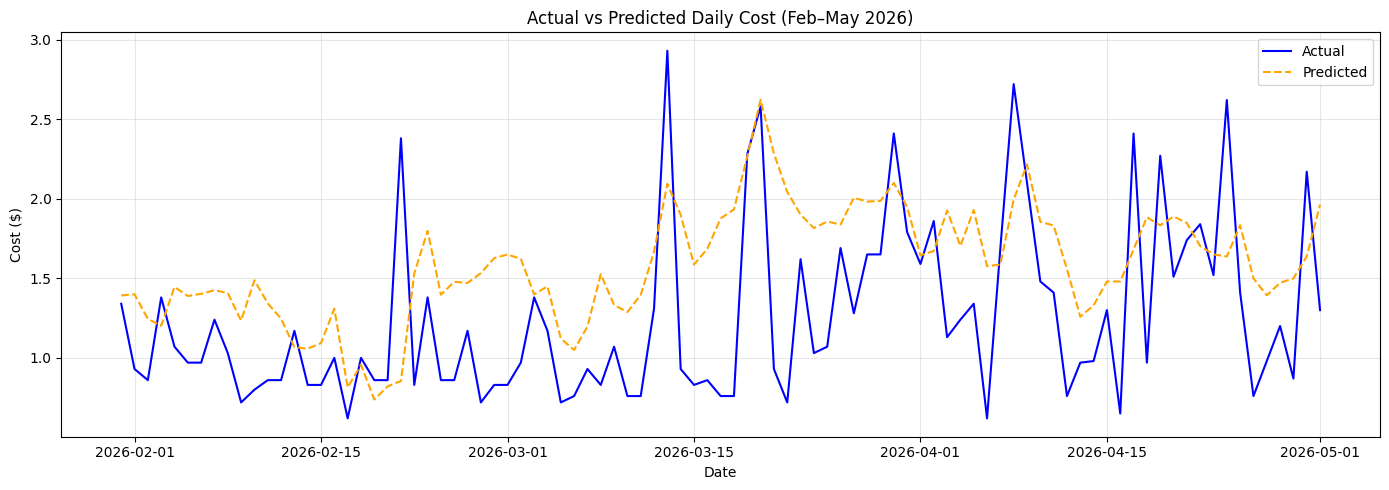

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df_val.index, df_val['total_cost_numeric'],
         label='Actual', color='blue', linewidth=1.5)
plt.plot(df_val.index, df_val['predicted'],
         label='Predicted', color='orange', linewidth=1.5, linestyle='--')
plt.title('Actual vs Predicted Daily Cost (Feb–May 2026)')
plt.xlabel('Date')
plt.ylabel('Cost ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Actual vs Predicted Daily Cost (Feb–May 2026)**

**Observations:**

- Model captures overall seasonal trend ✅
- Tracks cost direction correctly most of the time( Mar 15–20 cost spike) ✅
- Systematically model over-predicts(~$1.40 vs ~$1.00)  Feb 1–15 (lag1 seed effect).Also,Mar 1–15 — the over-prediction pattern we saw in error analysis.
- Misses sudden single-day spikes (Feb 21 anomaly)
- Predictions lag actuals by ~1 day(Model lags actual -orange line often follows blue with a delay) — expected with lag1 feature
- April predictions are reasonably close as model adjusts to shoulder season

**Residual plot**

Residual = Actual - Predicted

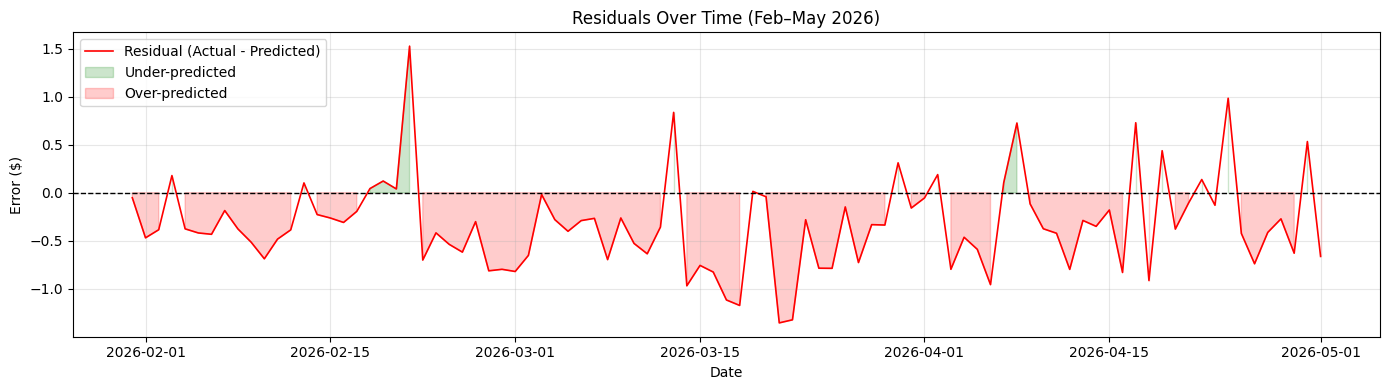

Mean residual : $-0.331  (negative = overall over-prediction)
Std residual  : $0.484
Max residual  : $1.525  (biggest under-prediction)
Min residual  : $-1.354  (biggest over-prediction)


In [63]:
plt.figure(figsize=(14, 4))
plt.plot(df_val.index, df_val['error'],
         color='red', linewidth=1.2, label='Residual (Actual - Predicted)')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.fill_between(df_val.index, df_val['error'], 0,
                 where=df_val['error'] > 0, color='green', alpha=0.2, label='Under-predicted')
plt.fill_between(df_val.index, df_val['error'], 0,
                 where=df_val['error'] < 0, color='red', alpha=0.2, label='Over-predicted')
plt.title('Residuals Over Time (Feb–May 2026)')
plt.xlabel('Date')
plt.ylabel('Error ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary stats
print(f"Mean residual : ${df_val['error'].mean():.3f}  (negative = overall over-prediction)")
print(f"Std residual  : ${df_val['error'].std():.3f}")
print(f"Max residual  : ${df_val['error'].max():.3f}  (biggest under-prediction)")
print(f"Min residual  : ${df_val['error'].min():.3f}  (biggest over-prediction)")

**Residual Analysis (Feb–May 2026)**

```
Mean residual : -$0.331  → model systematically over-predicts $0.33 high on average.Red (over-predicted) dominates the entire plot.
Std residual  : $0.484   → typical error spread
Max residual  : +$1.525  → Feb 21 anomalous spike (biggest under-prediction)
Min residual  : -$1.354  → Mar 21 biggest over-prediction

Key findings:
- Model has upward bias — predicts $0.33 higher than actual on average
- Likely cause: 2026 winter costs lower than 3-year training average
- Errors reduce through April — lag1 self-correction effect
- No systematic seasonal pattern in residuals beyond early bias
- One clear anomaly: Feb 21 unexplained cost spike
```
**Key events visible:**

```
Feb 21  : +$1.525  ← biggest under-prediction (anomalous expensive day)
Mar 21  : -$1.354  ← biggest over-prediction (model expected high, actual was low)
Feb 1–15: consistently red ← systematic over-prediction early in window
Apr onwards: errors smaller, model adjusting ✅
```

**Why the model over-predicts:**

The model was trained on 3 years of data where lag1 was strongly correlated with cost. But in Feb–May 2026, actual costs are running lower than the training period average ($1.25 vs training mean $2.69). The model expects costs to be higher based on historical patterns.

**Why the model under-predicts (Feb 21 specifically):**

Feb 21 actual=$2.38, predicted=$0.85 — off by $1.53

**For that day:**

```
temp_avg  : 57°F  ← cold day
is_weekend: 1     ← Saturday
srp_rate  : 9.70  ← pure winter rate
lag1      : $0.86 ← yesterday was cheap
```

Every signal pointed to a cheap day. Model had no reason to predict high. But actual cost was $2.38 — nearly 3x higher than predicted.

**Likely causes:**

- Guests visiting → unusual appliance usage
- Large appliance running all day (laundry, dishwasher repeatedly)
- Electric vehicle charging
- Any atypical household event

The fundamental reason:
**The model only knows:**

- What the weather was
- What day of the week it is
- What yesterday cost
- What the SRP rate is

**So, model under-predicts:**
- Anomalous household events (guests, unusual appliance usage)
- Model has no visibility into actual real-time usage behavior
- Irreducible error — cannot be fixed with current feature set
- Would require real-time kWh monitoring to capture